## Imports
First I will import the libraries that I will need for data processing, visualization, and forecasting.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

## Load dataset
Now I will load the dataset and check the date column. I will also create a `year_month` column for later use.


In [11]:
# load dataset
df = pd.read_csv("student_performance.csv")

# convert date
df['attempt_date'] = pd.to_datetime(df['attempt_date'])
df['year_month'] = df['attempt_date'].dt.to_period('M')

df.head()


,student_id,age,session_id,attempt_date,question_id,subject,question_text,student_answer,correct_answer,is_correct,time_taken,year_month
0,S001,12,Session1,2025-01-04,Q001,Science,What natural satellite orbits the Earth?,Moon,Moon,1,40,2025-01
1,S001,12,Session1,2025-01-04,Q002,Math,What is 45 + 28?,73,73,1,99,2025-01
2,S001,12,Session1,2025-01-04,Q003,History,In which year did World War II end?,1945,1945,1,38,2025-01
3,S001,12,Session1,2025-01-04,Q004,History,What is the capital of France?,Paris,Paris,1,5,2025-01
4,S001,12,Session1,2025-01-04,Q005,English,"Which is a verb: 'swim', 'blue', or 'quick'?",swim,swim,1,79,2025-01


## Basic dataset checks
Even though the dataset is generated and expected to be clean, it is good practice to check for missing values, duplicates, and data types.


In [13]:
# shape of dataset
print("Shape:", df.shape)

# data types
print("\nData types:")
print(df.dtypes)

# missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())

# basic statistics for numeric columns
df.describe()


Shape: (56021, 12)

Data types:
student_id                object
age                        int64
session_id                object
attempt_date      datetime64[ns]
question_id               object
subject                   object
question_text             object
student_answer            object
correct_answer            object
is_correct                 int64
time_taken                 int64
year_month             period[M]
dtype: object

Missing values per column:
student_id           0
age                  0
session_id           0
attempt_date         0
question_id          0
subject              0
question_text        0
student_answer    1945
correct_answer       0
is_correct           0
time_taken           0
year_month           0
dtype: int64

Number of duplicate rows: 0


,age,attempt_date,is_correct,time_taken
count,56021.000000,56021,56021.000000,56021.000000
mean,9.391585,2025-02-14 05:51:32.204708864,0.713804,57.553578
min,7.000000,2025-01-01 00:00:00,0.000000,5.000000
25%,8.000000,2025-01-23 00:00:00,0.000000,28.000000
50%,9.000000,2025-02-14 00:00:00,1.000000,57.000000
75%,11.000000,2025-03-09 00:00:00,1.000000,86.000000
max,12.000000,2025-03-31 00:00:00,1.000000,120.000000
std,1.747517,NaN,0.451986,33.574403


## Students
Now I will look at how many unique students there are and how many attempts they made. This will show how balanced the dataset is across students.


Unique students: 500


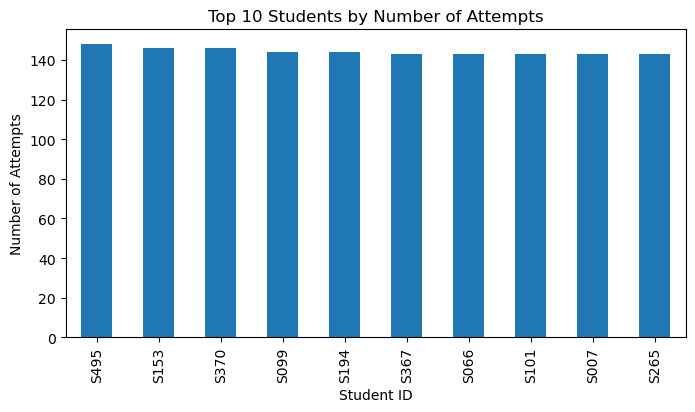

In [15]:
print("Unique students:", df['student_id'].nunique())

# plot top 10 students by attempts
df['student_id'].value_counts().head(10).plot(kind='bar', figsize=(8,4))
plt.title("Top 10 Students by Number of Attempts")
plt.xlabel("Student ID")
plt.ylabel("Number of Attempts")
plt.show()


## Subjects
I also want to check the distribution of attempts by subject. This helps to see if the dataset is balanced across subjects.


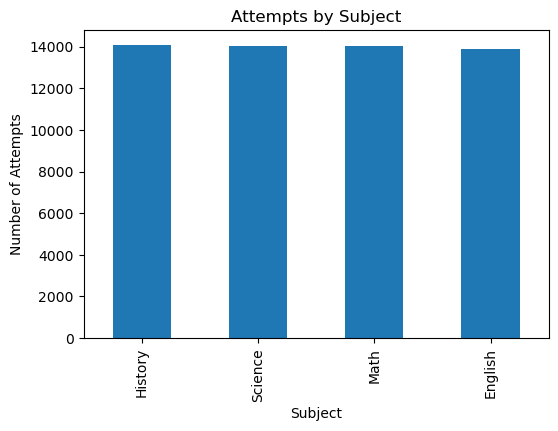

In [17]:
df['subject'].value_counts().plot(kind='bar', figsize=(6,4))
plt.title("Attempts by Subject")
plt.xlabel("Subject")
plt.ylabel("Number of Attempts")
plt.show()


## Accuracy overview
Here I will calculate the overall accuracy and then break it down by subject to see if some subjects are easier than others.


Overall Accuracy: 71.38%


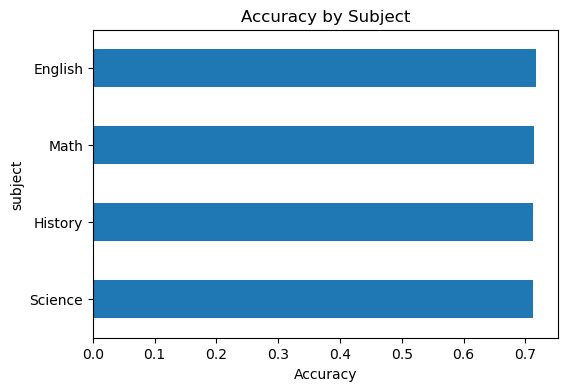

In [19]:
# overall accuracy
overall_accuracy = df['is_correct'].mean() * 100
print(f"Overall Accuracy: {overall_accuracy:.2f}%")

# accuracy per subject
df.groupby('subject')['is_correct'].mean().sort_values().plot(kind='barh', figsize=(6,4))
plt.title("Accuracy by Subject")
plt.xlabel("Accuracy")
plt.show()


## Trends over time
Since we have attempt dates, I will check how accuracy changes month by month overall.


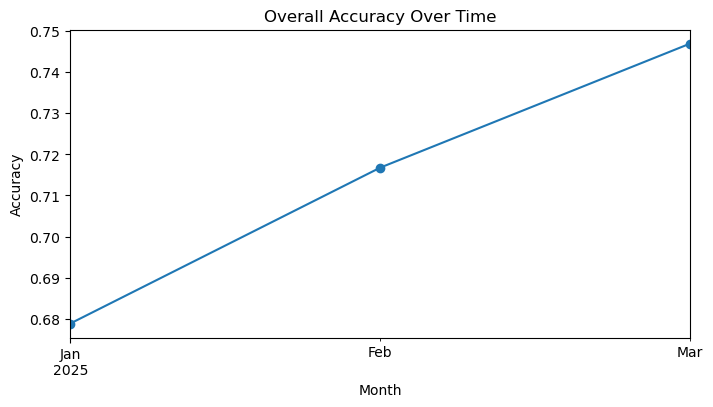

In [21]:
monthly_accuracy = df.groupby('year_month')['is_correct'].mean()

monthly_accuracy.plot(marker='o', figsize=(8,4))
plt.title("Overall Accuracy Over Time")
plt.ylabel("Accuracy")
plt.xlabel("Month")
plt.show()


## Forecasting accuracy with Arima
Finally, I will try to forecast accuracy in the future using the Arima library.  


In [25]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings("ignore")

# container for forecasts
student_forecasts = []

# loop over students
for sid, student_data in df.groupby("student_id"):
    # aggregate by week
    weekly_acc = student_data.groupby(student_data['attempt_date'].dt.to_period('W'))['is_correct'].mean()
    weekly_acc.index = weekly_acc.index.to_timestamp()
    
    if len(weekly_acc) < 3:  # not enough data for ARIMA
        continue
    
    # fit ARIMA model (basic order, can tune)
    model = ARIMA(weekly_acc, order=(1,1,1))
    model_fit = model.fit()
    
    # forecast 1 step ahead (next week)
    forecast = model_fit.forecast(steps=1)
    student_forecasts.append((sid, forecast.values[0]))

# build results table
forecast_df = pd.DataFrame(student_forecasts, columns=["student_id", "next_week_accuracy_forecast"])
forecast_df["next_week_accuracy_forecast"] = (forecast_df["next_week_accuracy_forecast"]*100).round(2)
forecast_df


,student_id,next_week_accuracy_forecast
0,S001,41.71
1,S002,70.91
2,S003,66.39
3,S004,66.11
4,S005,40.34
...,...,...
495,S496,100.00
496,S497,61.28
497,S498,88.74
498,S499,64.62


Training MAE: 0.1383
Training RMSE: 0.1931


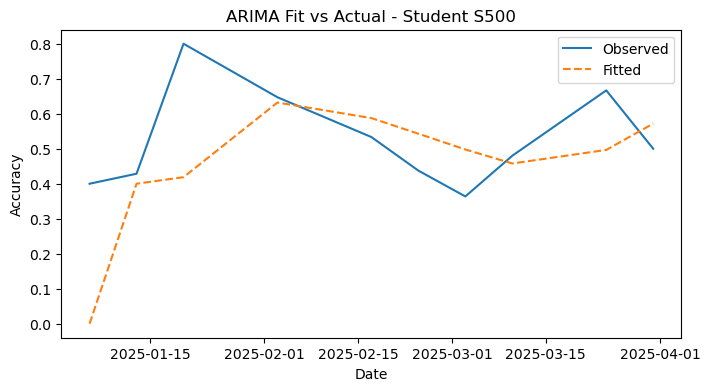

In [27]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Fitted values vs actual
fitted_values = model_fit.fittedvalues

# Error metrics
mae = mean_absolute_error(weekly_acc, fitted_values)
rmse = np.sqrt(mean_squared_error(weekly_acc, fitted_values))

print(f"Training MAE: {mae:.4f}")
print(f"Training RMSE: {rmse:.4f}")

# Plot actual vs fitted
plt.figure(figsize=(8,4))
plt.plot(weekly_acc.index, weekly_acc, label="Observed")
plt.plot(weekly_acc.index, fitted_values, label="Fitted", linestyle="--")
plt.title(f"ARIMA Fit vs Actual - Student {sid}")
plt.xlabel("Date")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


count    10.000000
mean      0.065161
std       0.191656
min      -0.134174
25%      -0.067411
50%       0.018607
75%       0.134736
max       0.400000
dtype: float64


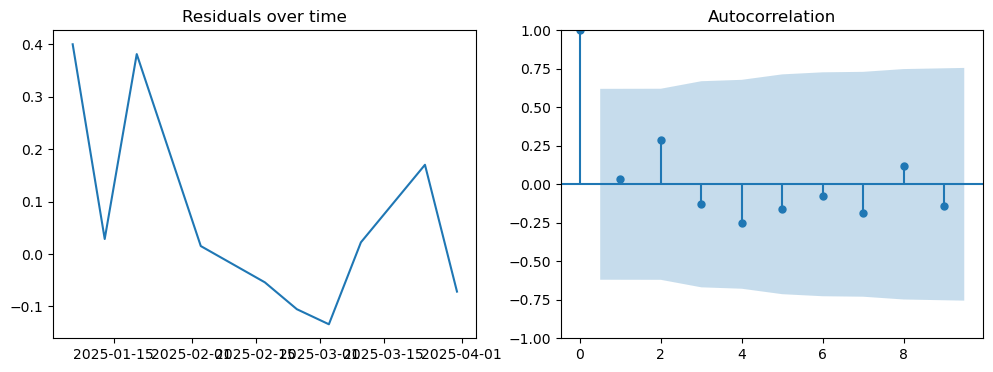

Ljung-Box test p-value: 0.518632270836796


In [33]:
import statsmodels.api as sm

# Residuals
residuals = model_fit.resid

# Summary stats
print(residuals.describe())

# Plot residuals
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(residuals)
axes[0].set_title("Residuals over time")

# Limit lags to avoid errors with small series
max_lags = min(20, len(residuals)-1)
sm.graphics.tsa.plot_acf(residuals, lags=max_lags, ax=axes[1])
plt.show()

# Ljung-Box test (are residuals white noise?)
lb_test = sm.stats.acorr_ljungbox(residuals, lags=[min(10, len(residuals)-1)], return_df=True)
print("Ljung-Box test p-value:", lb_test['lb_pvalue'].values[0])


Test MAE: 0.0901
Test RMSE: 0.1243


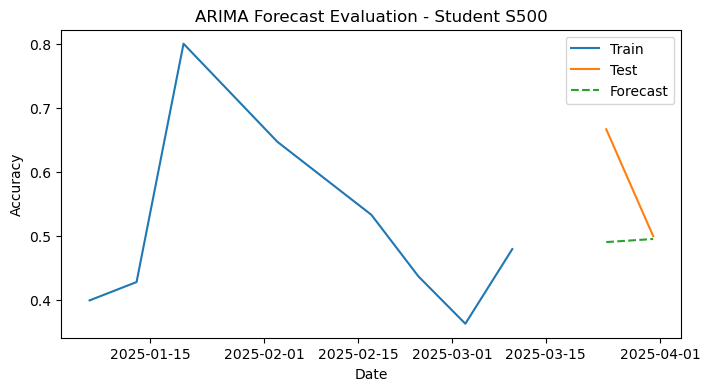

In [35]:
# Split: all but last 2 weeks for training, last 2 for testing
train = weekly_acc[:-2]
test = weekly_acc[-2:]

# Fit ARIMA on training set
model = ARIMA(train, order=(1,1,1))
model_fit_train = model.fit()

# Forecast test period
forecast = model_fit_train.forecast(steps=len(test))

# Evaluate errors
mae_test = mean_absolute_error(test, forecast)
rmse_test = np.sqrt(mean_squared_error(test, forecast))

print(f"Test MAE: {mae_test:.4f}")
print(f"Test RMSE: {rmse_test:.4f}")

# Plot
plt.figure(figsize=(8,4))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, forecast, label="Forecast", linestyle="--")
plt.title(f"ARIMA Forecast Evaluation - Student {sid}")
plt.xlabel("Date")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [40]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

results = []

# loop through each student
for sid, student_data in df.groupby("student_id"):
    weekly_acc = student_data.groupby(student_data['attempt_date'].dt.to_period('W'))['is_correct'].mean()
    weekly_acc.index = weekly_acc.index.to_timestamp()

    # only run if enough data
    if len(weekly_acc) >= 5:
        try:
            # train/test split (last 2 weeks for test)
            train = weekly_acc[:-2]
            test = weekly_acc[-2:]

            model = ARIMA(train, order=(1,1,1))
            model_fit = model.fit()

            forecast = model_fit.forecast(steps=len(test))

            # calculate errors
            mae = mean_absolute_error(test, forecast)
            rmse = np.sqrt(mean_squared_error(test, forecast))

            results.append({"student_id": sid, "MAE": mae, "RMSE": rmse})

        except Exception as e:
            results.append({"student_id": sid, "MAE": None, "RMSE": None})

# create dataframe
results_df = pd.DataFrame(results)

# drop missing
results_df = results_df.dropna()

# summary stats
print("Average MAE across students:", results_df["MAE"].mean())
print("Average RMSE across students:", results_df["RMSE"].mean())

results_df


Average MAE across students: 0.1355717323107525
Average RMSE across students: 0.14826704278771144


,student_id,MAE,RMSE
0,S001,0.204383,0.215467
1,S002,0.225109,0.262987
2,S003,0.131888,0.154191
3,S004,0.066809,0.069513
4,S005,0.237380,0.238196
...,...,...,...
495,S496,0.000024,0.000028
496,S497,0.345363,0.357979
497,S498,0.157049,0.165229
498,S499,0.143273,0.176574


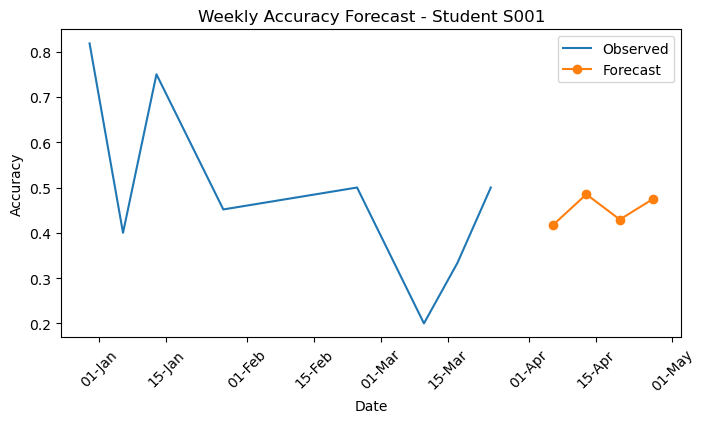

In [37]:
import matplotlib.dates as mdates

sid = "S001"
student_data = df[df['student_id'] == sid]
weekly_acc = student_data.groupby(student_data['attempt_date'].dt.to_period('W'))['is_correct'].mean()
weekly_acc.index = weekly_acc.index.to_timestamp()

model = ARIMA(weekly_acc, order=(1,1,1))
model_fit = model.fit()
forecast = model_fit.forecast(steps=4)  # next 4 weeks

plt.figure(figsize=(8,4))
plt.plot(weekly_acc.index, weekly_acc, label="Observed")
plt.plot(pd.date_range(weekly_acc.index[-1] + pd.offsets.Week(), periods=4, freq="W"),
         forecast, marker="o", label="Forecast")

# format x-axis to show only day and month (no year)
ax = plt.gca()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d-%b"))  # e.g. 15-Mar
plt.xticks(rotation=45)

plt.title(f"Weekly Accuracy Forecast - Student {sid}")
plt.ylabel("Accuracy")
plt.xlabel("Date")
plt.legend()
plt.show()


## Conclusion
From the EDA we checked dataset quality (missing values, duplicates, etc.),  
then explored students, subjects, and accuracy trends.  
Finally, we used Arima to forecast accuracy into the future, and we also evaluated Arima.